In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('Health_Sleep_Statistics.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   User ID                  100 non-null    int64
 1   Age                      100 non-null    int64
 2   Gender                   100 non-null    str  
 3   Sleep Quality            100 non-null    int64
 4   Bedtime                  100 non-null    str  
 5   Wake-up Time             100 non-null    str  
 6   Daily Steps              100 non-null    int64
 7   Calories Burned          100 non-null    int64
 8   Physical Activity Level  100 non-null    str  
 9   Dietary Habits           100 non-null    str  
 10  Sleep Disorders          100 non-null    str  
 11  Medication Usage         100 non-null    str  
dtypes: int64(5), str(7)
memory usage: 9.5 KB


In [5]:
df['Physical Activity Level'].value_counts()

Physical Activity Level
medium    38
high      36
low       26
Name: count, dtype: int64

Examinar si el nivel de actividad física (alta vs. baja) afecta significativamente
la calidad del sueño.


<h3>Box-plot

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

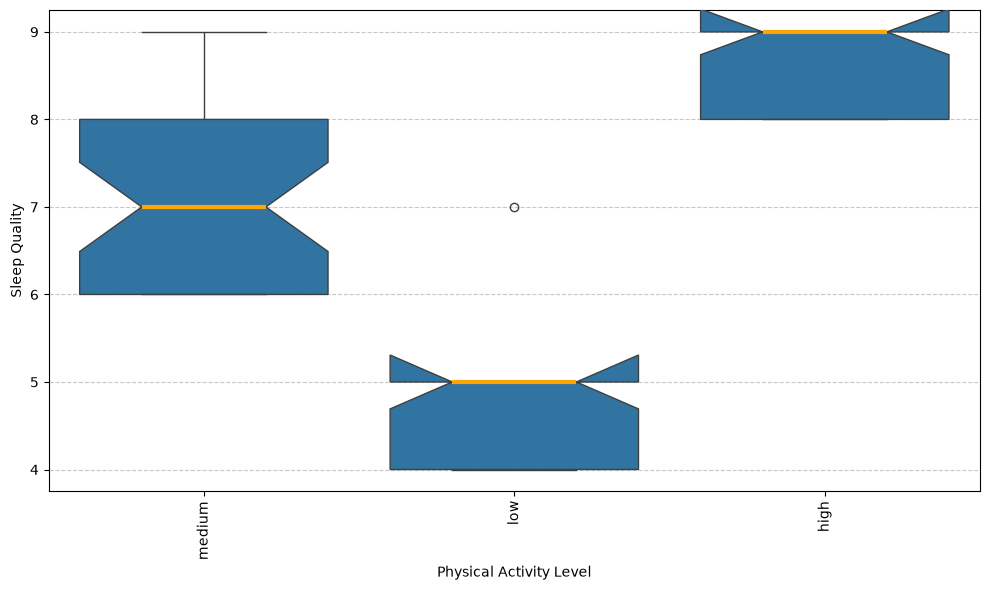

In [7]:
utils.box_plot('Physical Activity Level', 'Sleep Quality', df, note=True)

In [8]:
low_activity = df[df['Physical Activity Level'] == 'low']
high_activity = df[df['Physical Activity Level'] == 'high']

<h3>Normalidad

In [10]:
import scipy.stats as stats

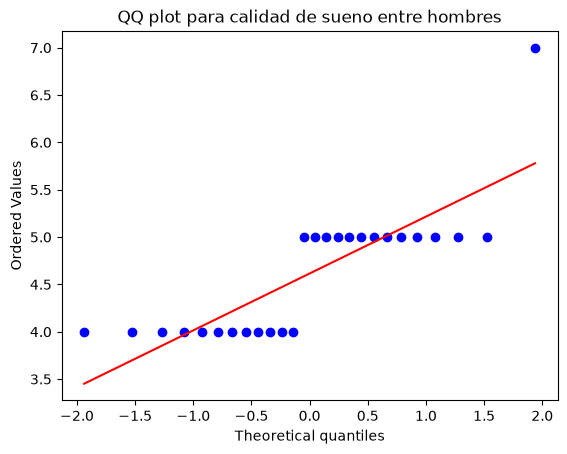

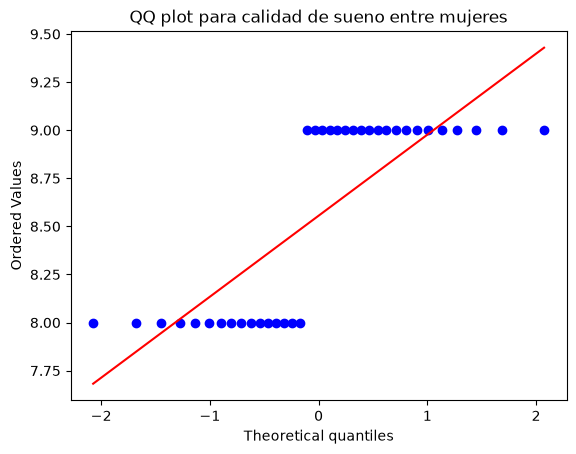

In [11]:
#QQ plot
stats.probplot(low_activity['Sleep Quality'], dist='norm', plot=plt)
plt.title('QQ plot para calidad de sueno entre hombres')
plt.show()

stats.probplot(high_activity['Sleep Quality'], dist='norm', plot=plt)
plt.title('QQ plot para calidad de sueno entre mujeres')
plt.show()

In [19]:
from scipy.stats import shapiro

In [16]:
stat, p = shapiro(low_activity['Sleep Quality'])
print(f"Test de Shapiro-Wilk para calidad de sueno con actividad fisica baja: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para calidad de sueno con actividad fisica baja: Estadístico=0.693, p-valor=0.000


In [15]:
stat, p = shapiro(high_activity['Sleep Quality'])
print(f"Test de Shapiro-Wilk para calidad de sueno con actividad fisica alta: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para calidad de sueno con actividad fisica alta: Estadístico=0.633, p-valor=0.000


<h3>Homocedasticidad

In [17]:
stat, p = stats.levene(high_activity['Sleep Quality'], low_activity['Sleep Quality'])
print(f"Test de Levene para calidad de sueno: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para calidad de sueno: Estadístico=0.461, p-valor=0.500


Podemos ver que las varianzas no son significtativamente diferentes, por lo que esto nos habilita a usar Mann-Whitney

<h3>Mann-Whitney

In [22]:
# Test de Mann-Whitney U para comparar Population_mln entre países desarrollados y en vías de desarrollo
stat, p = stats.mannwhitneyu(high_activity['Sleep Quality'], low_activity['Sleep Quality'])
print(f"Test de Mann-Whitney U para Population_mln: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en la calidad de sueno entre actividad fisica baja o alta.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en la calidad de sueno entre actividad fisica baja o alta.")

Test de Mann-Whitney U para Population_mln: Estadístico=936.000, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en la calidad de sueno entre actividad fisica baja o alta.
